## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')


## 2. Đọc dữ liệu

In [2]:
df_success = pd.read_csv('../data/df_success.csv')
df_success['InvoiceDate'] = pd.to_datetime(df_success['InvoiceDate'])
df_success.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 3. Tính RFM (Recency - Frequency - Monetary)

In [3]:
now = df_success['InvoiceDate'].max() + pd.Timedelta(days=1)

customer = df_success.groupby('Customer ID').agg({
    'Country': 'first',
    'InvoiceDate': lambda x: (now - x.max()).days,
    'Amount': 'sum',
    'Invoice': 'nunique'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Amount': 'Monetary',
    'Invoice': 'Frequency'
})

print(f"Tổng số khách hàng: {len(customer)}")
customer[['Recency', 'Monetary', 'Frequency']].describe()


Tổng số khách hàng: 4314


,Recency,Monetary,Frequency
count,4314.000000,4314.000000,4314.000000
mean,91.269124,2047.288659,4.454103
std,96.943482,8912.523243,8.168658
min,1.000000,0.000000,1.000000
25%,18.000000,307.950000,1.000000
50%,53.000000,705.550000,2.000000
75%,136.000000,1722.802500,5.000000
max,374.000000,349164.350000,205.000000


## 4. Tách nhóm "Siêu VIP" trước khi phân cụm

In [4]:
Q1 = customer['Monetary'].quantile(0.25)
Q3 = customer['Monetary'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

customer['Is_Outlier'] = customer['Monetary'] > upper_bound

print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Ngưỡng outlier (Upper bound) = {upper_bound:.2f}")
print(f"Số khách Siêu VIP: {customer['Is_Outlier'].sum()} ({customer['Is_Outlier'].mean()*100:.1f}%)")
print(f"Số khách bình thường: {(~customer['Is_Outlier']).sum()} ({(~customer['Is_Outlier']).mean()*100:.1f}%)")


Q1=307.95, Q3=1722.80, IQR=1414.85
Ngưỡng outlier (Upper bound) = 3845.08
Số khách Siêu VIP: 428 (9.9%)
Số khách bình thường: 3886 (90.1%)


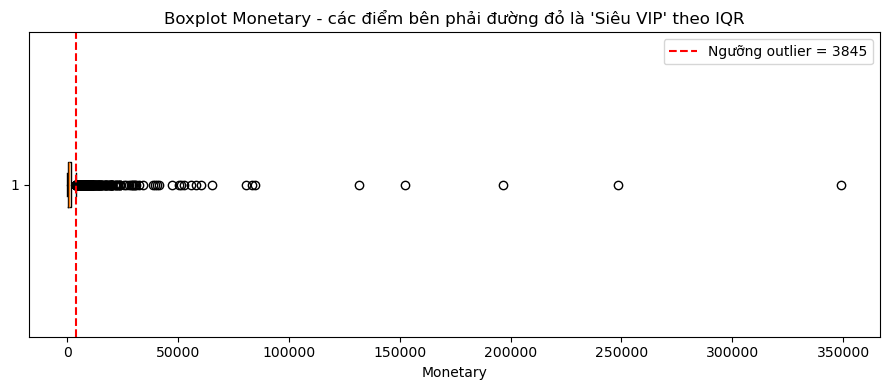

In [5]:
plt.figure(figsize=(9,4))
plt.boxplot(customer['Monetary'], vert=False)
plt.axvline(upper_bound, color='red', linestyle='--', label=f'Ngưỡng outlier = {upper_bound:.0f}')
plt.title("Boxplot Monetary - các điểm bên phải đường đỏ là 'Siêu VIP' theo IQR")
plt.xlabel('Monetary')
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
vip = customer[customer['Is_Outlier']].copy()
normal = customer[~customer['Is_Outlier']].copy()

vip['Segment'] = 'Champions'
vip['Cluster'] = -1  # đánh dấu: nhóm này tách riêng bằng ngưỡng, không cho qua KMeans

print("Thống kê nhanh nhóm Siêu VIP:")
print(vip[['Recency','Monetary','Frequency']].agg(['mean','median']).round(2))


Thống kê nhanh nhóm Siêu VIP:
        Recency  Monetary  Frequency
mean      30.88  12319.51      17.28
median    14.00   6262.58      12.00


## 5. Xử lý dữ liệu cho clustering (chỉ trên phần `normal`)


In [7]:
rfm_log = normal.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])


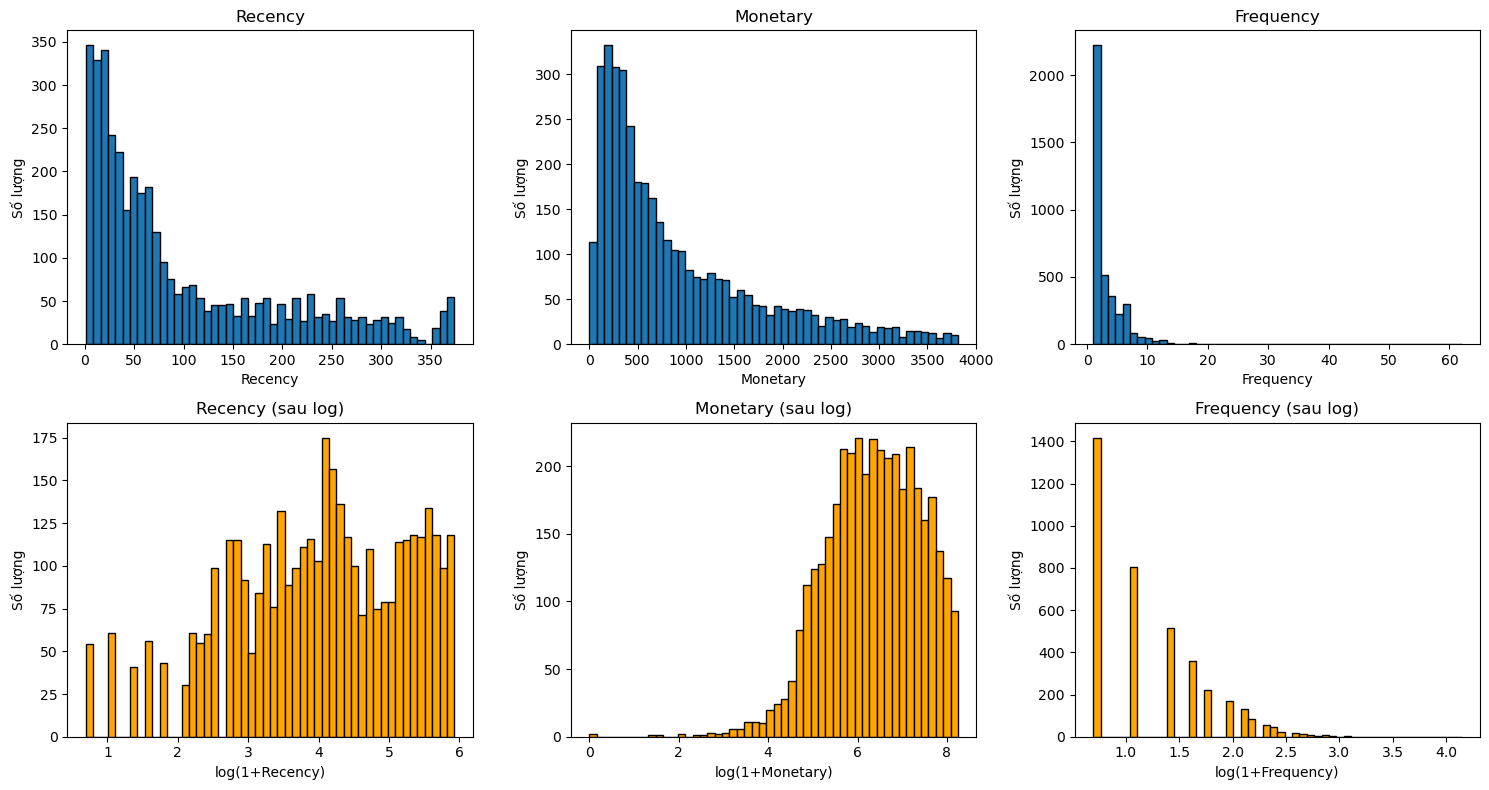

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['Recency', 'Monetary', 'Frequency']

for i, feature in enumerate(features):
    axes[0, i].hist(normal[feature], bins=50, edgecolor='black')
    axes[0, i].set_title(f'{feature}')
    axes[0, i].set_xlabel(feature)
    axes[0, i].set_ylabel('Số lượng')

    axes[1, i].hist(rfm_log[feature], bins=50, edgecolor='black', color='orange')
    axes[1, i].set_title(f'{feature} (sau log)')
    axes[1, i].set_xlabel(f'log(1+{feature})')
    axes[1, i].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()


In [9]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Monetary', 'Frequency']])
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Monetary', 'Frequency'],
    index=rfm_log.index
)


## 6. Tìm K tối ưu bằng Elbow method

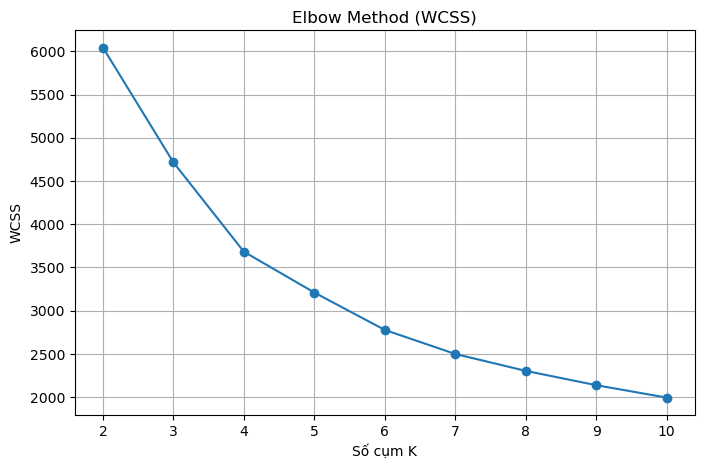

In [10]:
K_range = range(2, 11)
wcss = []

for k in K_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_tmp.fit(rfm_scaled)
    wcss.append(kmeans_tmp.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Số cụm K')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


Nhìn biểu đồ, đường cong bắt đầu gãy khúc quanh **K = 3** (từ K=3 trở đi WCSS giảm chậm hẳn lại
so với đoạn K=2 sang K=3). Nên mình chọn K = 3.

In [11]:
optimal_k = 3


## 7. Phân cụm với K tối ưu (trên `normal`)

In [12]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_scaled['Cluster'] = kmeans.fit_predict(rfm_scaled[['Recency', 'Monetary', 'Frequency']])
normal['Cluster'] = rfm_scaled['Cluster']


## 8. Phân tích đặc điểm từng cluster

In [13]:
cluster_summary_scaled = rfm_scaled.groupby('Cluster')[['Recency', 'Monetary', 'Frequency']].mean()
print("Đặc điểm các cluster (dữ liệu đã chuẩn hóa):")
print(cluster_summary_scaled.round(4))

cluster_summary_original = normal.groupby('Cluster')[['Recency', 'Monetary', 'Frequency']].agg(['mean', 'median'])
print("\nĐặc điểm các cluster (dữ liệu gốc):")
print(cluster_summary_original.round(2))


Đặc điểm các cluster (dữ liệu đã chuẩn hóa):
         Recency  Monetary  Frequency
Cluster                              
0         0.0349    0.3616     0.0891
1         0.5927   -0.9545    -0.8816
2        -1.0666    1.0347     1.3560

Đặc điểm các cluster (dữ liệu gốc):
        Recency        Monetary          Frequency       
           mean median     mean   median      mean median
Cluster                                                  
0         80.23   59.0   989.77   806.44      2.78    3.0
1        159.52  148.0   255.85   231.34      1.18    1.0
2         21.91   15.0  1919.42  1849.20      6.64    6.0


## 9. Gán nhãn phân khúc

In [14]:
def assign_segment(cluster_id):
    sorted_clusters = cluster_summary_scaled.sort_values('Monetary', ascending=False).index.tolist()

    if cluster_id == sorted_clusters[0]:
        return 'Loyalists'
    elif cluster_id == sorted_clusters[-1]:
        return 'Need Attention'
    else:
        return 'High-Potential'

normal['Segment'] = normal['Cluster'].apply(assign_segment)

# Ghép lại vip và normal thành 1 bảng khách hàng đầy đủ
customer = pd.concat([vip, normal])
print(customer['Segment'].value_counts())


Segment
Need Attention    1526
High-Potential    1464
Loyalists          896
Champions          428
Name: count, dtype: int64


## 10. Trực quan hóa bằng PCA

2 thành phần PCA giữ lại được 91.5% biến thiên của dữ liệu gốc


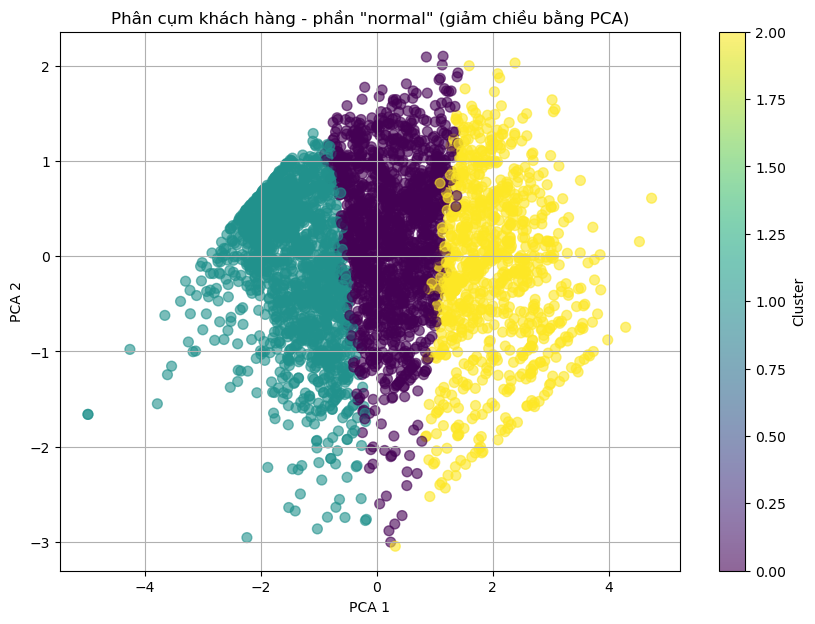

In [15]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled[['Recency', 'Monetary', 'Frequency']])
rfm_scaled['PCA1'] = rfm_pca[:, 0]
rfm_scaled['PCA2'] = rfm_pca[:, 1]

print(f"2 thành phần PCA giữ lại được {pca.explained_variance_ratio_.sum()*100:.1f}% biến thiên của dữ liệu gốc")

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    rfm_scaled['PCA1'],
    rfm_scaled['PCA2'],
    c=rfm_scaled['Cluster'],
    cmap='viridis',
    alpha=0.6,
    s=50
)
plt.title('Phân cụm khách hàng - phần "normal" (giảm chiều bằng PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()


## 11. Phân bổ khách hàng theo từng segment (toàn bộ, gồm cả Champions)

PHÂN PHỐI KHÁCH HÀNG THEO SEGMENT:
Segment
Need Attention    1526
High-Potential    1464
Loyalists          896
Champions          428
Name: count, dtype: int64

Tỷ lệ phần trăm:
Segment
Need Attention    35.4
High-Potential    33.9
Loyalists         20.8
Champions          9.9
Name: count, dtype: float64


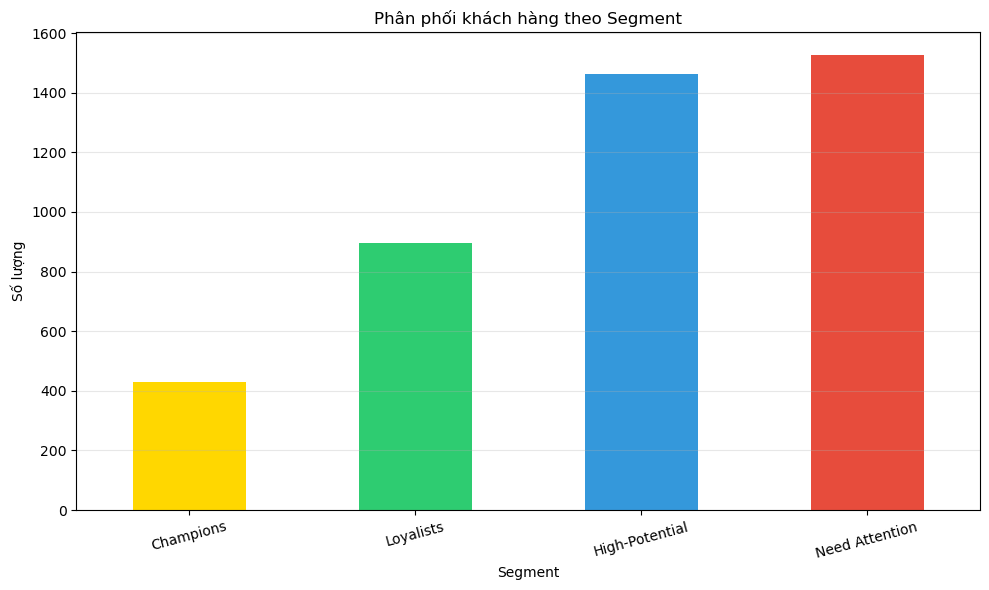

In [16]:
segment_counts = customer['Segment'].value_counts()
print("PHÂN PHỐI KHÁCH HÀNG THEO SEGMENT:")
print(segment_counts)
print("\nTỷ lệ phần trăm:")
print((segment_counts / len(customer) * 100).round(1))

order = ['Champions', 'Loyalists', 'High-Potential', 'Need Attention']
plt.figure(figsize=(10, 6))
segment_counts.reindex(order).plot(kind='bar', color=['#FFD700', '#2ECC71', '#3498DB', '#E74C3C'])
plt.title('Phân phối khách hàng theo Segment')
plt.xlabel('Segment')
plt.ylabel('Số lượng')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Chi tiết từng segment

In [17]:
segment_profile = customer.groupby('Segment')[['Recency', 'Monetary', 'Frequency']].agg(['mean', 'median'])
print("ĐẶC ĐIỂM CHI TIẾT TỪNG SEGMENT:")
print(segment_profile.round(2))


ĐẶC ĐIỂM CHI TIẾT TỪNG SEGMENT:
               Recency         Monetary          Frequency       
                  mean median      mean   median      mean median
Segment                                                          
Champions        30.88   14.0  12319.51  6262.58     17.28   12.0
High-Potential   80.23   59.0    989.77   806.44      2.78    3.0
Loyalists        21.91   15.0   1919.42  1849.20      6.64    6.0
Need Attention  159.52  148.0    255.85   231.34      1.18    1.0


## 13. Lưu kết quả

In [18]:
customer.to_csv('../data/customer_segmented.csv', index=True)
print("Đã lưu file 'customer_segmented.csv'")

import joblib
joblib.dump(kmeans, '../models/kmeans_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("Đã lưu model KMeans và scaler")


Đã lưu file 'customer_segmented.csv'
Đã lưu model KMeans và scaler


## 14. Top khách hàng

In [19]:
top_customers = customer.nlargest(5, 'Monetary')
print("TOP 5 KHÁCH HÀNG THEO MONETARY:")
print(top_customers[['Recency', 'Monetary', 'Frequency', 'Segment']])


TOP 5 KHÁCH HÀNG THEO MONETARY:
             Recency   Monetary  Frequency    Segment
Customer ID                                          
18102.0            1  349164.35         89  Champions
14646.0           10  248396.50         78  Champions
14156.0            7  196566.74        102  Champions
14911.0            1  152147.57        205  Champions
13694.0            9  131443.19         94  Champions
